# **Customer Support Eda Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/customer_support_analytics.csv')

Data Loading

In [ ]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

  Ticket_ID Customer_ID Ticket_Date Month  Month_Number  Gender   Region  \
0  TKT10001    CUST3430  13-04-2025   Apr             4    Male  Central   
1  TKT10002    CUST6462  15-12-2025   Dec            12  Female  Central   
2  TKT10003    CUST6518  28-09-2025   Sep             9    Male     West   
3  TKT10004    CUST4109  17-04-2025   Apr             4  Female    South   
4  TKT10005    CUST3032  13-03-2025   Mar             3    Male    South   

  Customer_Type  Department         Issue_Type  ... Resolution_Time_Days  \
0           New  IT Support    Technical Issue  ...                  7.5   
1       Premium     Billing    Technical Issue  ...                  NaN   
2       Premium    Delivery     Refund Request  ...                  6.3   
3      Existing  IT Support    Technical Issue  ...                  NaN   
4      Existing     Billing  Product Complaint  ...                  4.8   

  SLA_Target_Days SLA_Breached  Escalated  CSAT_Rating  Priority  \
0               5 

Data Cleaning

In [ ]:
df.isnull().sum()

,0
Ticket_ID,0
Customer_ID,0
Ticket_Date,0
Month,0
Month_Number,0
Gender,0
Region,0
Customer_Type,0
Department,0
Issue_Type,0


In [ ]:
median_time = df['Resolution_Time_Days'].median()
df['Resolution_Time_Days'].fillna(median_time, inplace=True)

/tmp/ipykernel_9022/81703836.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Resolution_Time_Days'].fillna(median_time, inplace=True)


Duplicate Value Check

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Ticket_Date'] = pd.to_datetime(df['Ticket_Date'], dayfirst=True)

Most tickets are resolved successfully.
Pending tickets still create operational backlog.

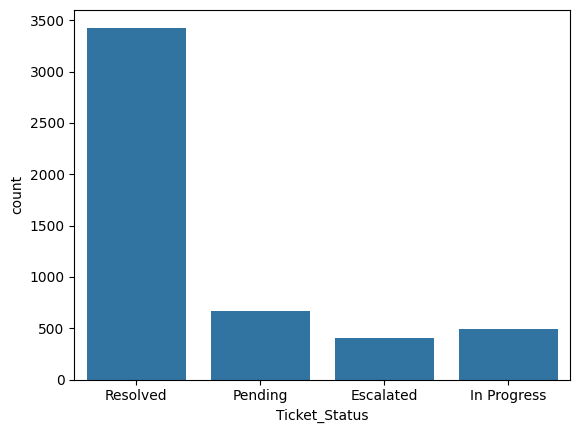

In [ ]:
sns.countplot(x='Ticket_Status', data=df)
plt.show()

Existing customers generate the highest number of tickets.
Premium customers require high-quality support.

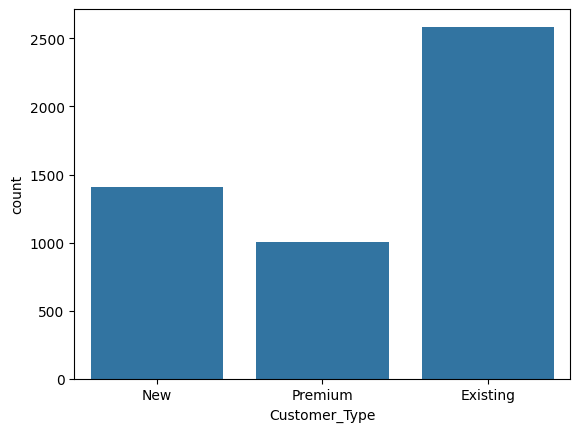

In [ ]:
sns.countplot(x='Customer_Type', data=df)
plt.show()

Customer satisfaction is mostly centered around average ratings.
Lower ratings indicate service improvement opportunities.

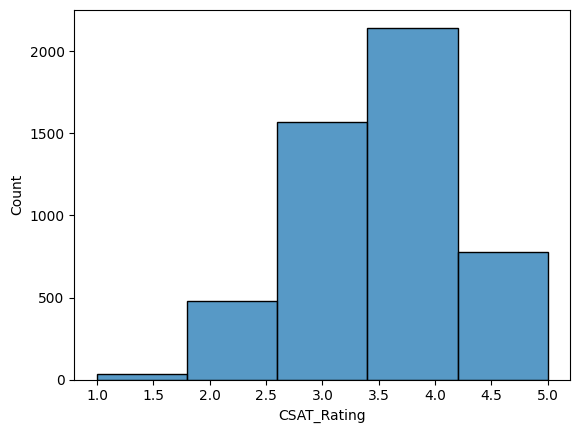

In [ ]:
sns.histplot(df['CSAT_Rating'], bins=5)
plt.show()

SLA-breached tickets show lower customer satisfaction.
Delayed resolutions negatively impact customer experience.

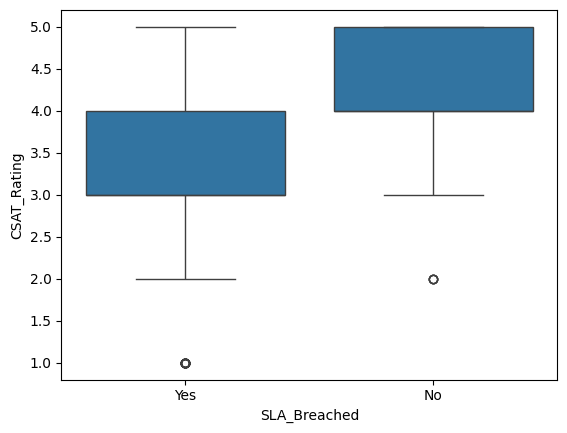

In [ ]:
sns.boxplot(x='SLA_Breached', y='CSAT_Rating', data=df)
plt.show()

Critical tickets generally require higher handling time.
Low-priority tickets are resolved comparatively faster.

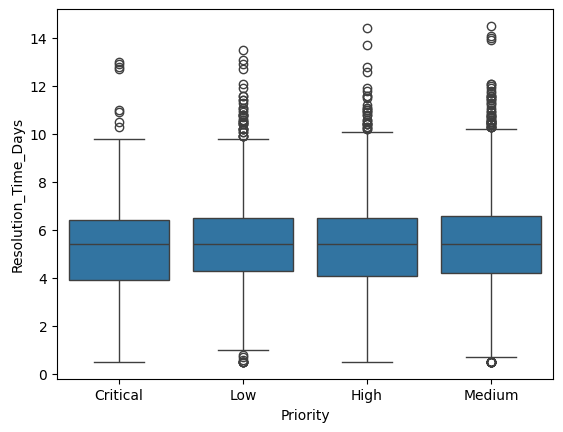

In [ ]:
sns.boxplot(x='Priority', y='Resolution_Time_Days', data=df)
plt.show()

Escalated tickets are more likely to remain pending.


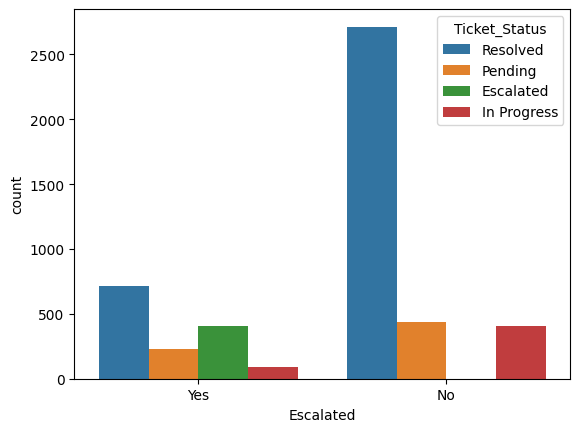

In [ ]:
sns.countplot(x='Escalated', hue='Ticket_Status', data=df)
plt.show()

SLA breach positively correlates with escalations.
Resolution time negatively impacts CSAT rating.
Escalated tickets generally increase service delays.

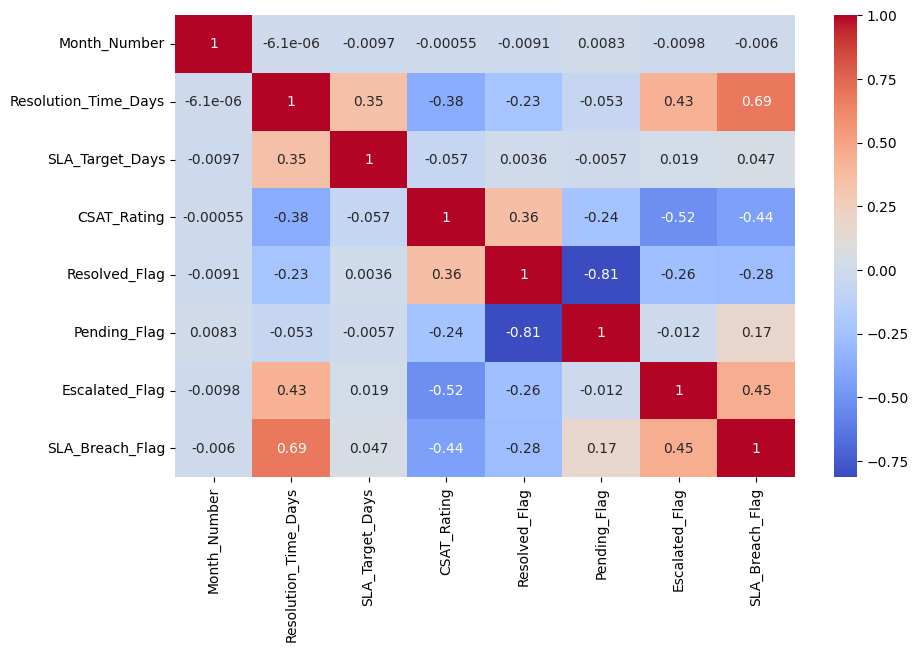

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

Ticket Resolution Trend

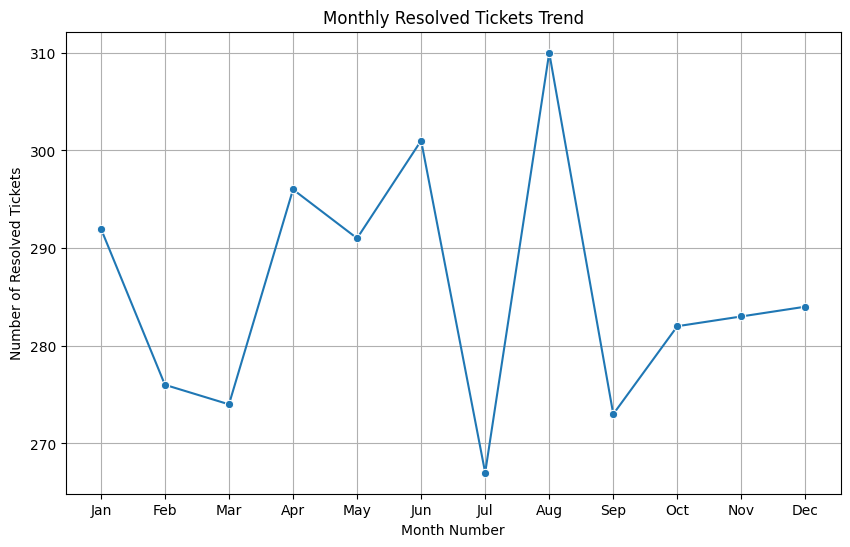

In [ ]:
resolved_tickets_monthly = df[df['Resolved_Flag'] == 1].groupby('Month_Number')['Ticket_ID'].count().reset_index()
resolved_tickets_monthly = resolved_tickets_monthly.sort_values('Month_Number')

plt.figure(figsize=(10, 6))
sns.lineplot(x='Month_Number', y='Ticket_ID', data=resolved_tickets_monthly, marker='o')
plt.title('Monthly Resolved Tickets Trend')
plt.xlabel('Month Number')
plt.ylabel('Number of Resolved Tickets')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

Highest Support Risk Analysis

Escalated,No,Yes
SLA_Breached,,
No,4.181050,NaN
Yes,3.705013,2.912293


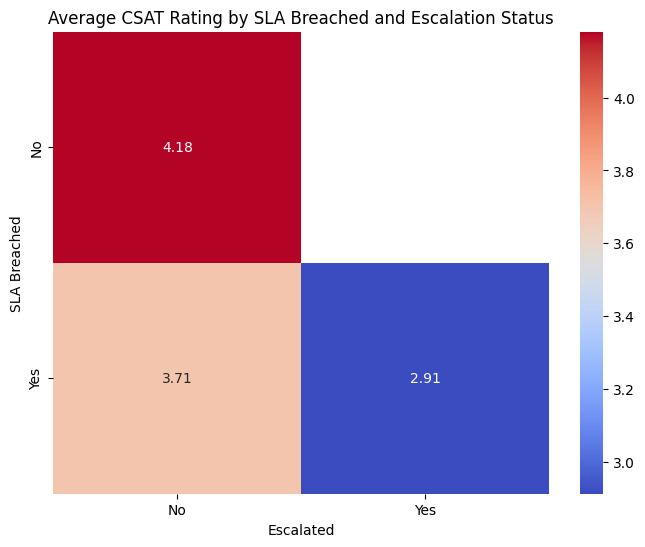

In [ ]:
risk_analysis = df.groupby(['SLA_Breached', 'Escalated'])['CSAT_Rating'].mean().unstack()
display(risk_analysis)

plt.figure(figsize=(8, 6))
sns.heatmap(risk_analysis, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Average CSAT Rating by SLA Breached and Escalation Status')
plt.xlabel('Escalated')
plt.ylabel('SLA Breached')
plt.show()

Ticket Distribution by Issue Type

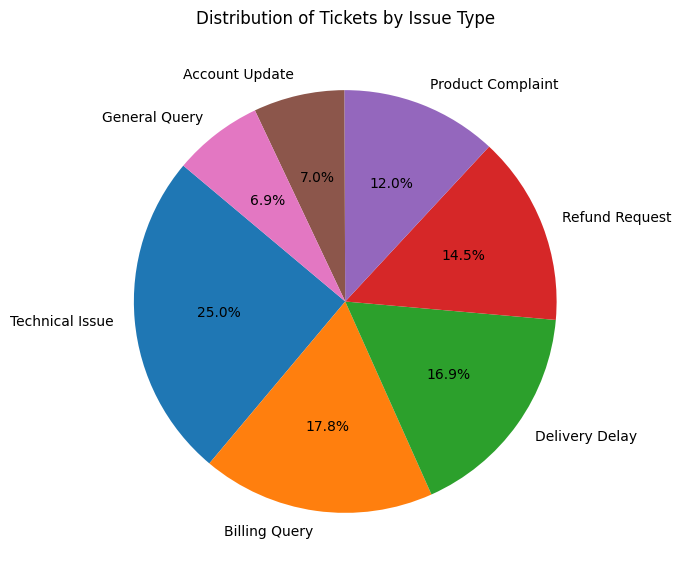

In [ ]:
issue_type_counts = df['Issue_Type'].value_counts()

plt.figure(figsize=(6, 7))
plt.pie(issue_type_counts, labels=issue_type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Tickets by Issue Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

SLA Breach by Average Resolution Time

/tmp/ipykernel_9022/2156216874.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SLA_Breached', y='Resolution_Time_Days', data=avg_resolution_time_sla, palette='coolwarm')


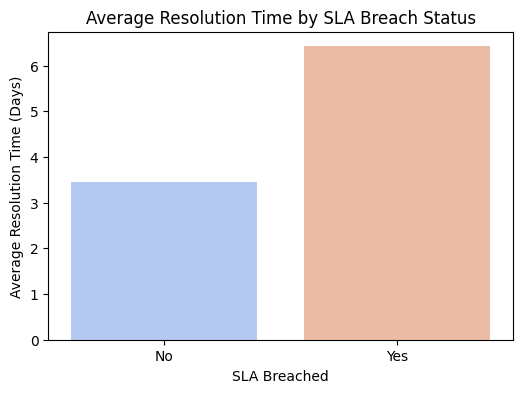

In [ ]:
avg_resolution_time_sla = df.groupby('SLA_Breached')['Resolution_Time_Days'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(x='SLA_Breached', y='Resolution_Time_Days', data=avg_resolution_time_sla, palette='coolwarm')
plt.title('Average Resolution Time by SLA Breach Status')
plt.xlabel('SLA Breached')
plt.ylabel('Average Resolution Time (Days)')
plt.show()

### Resolution Time by SLA Status and Escalation

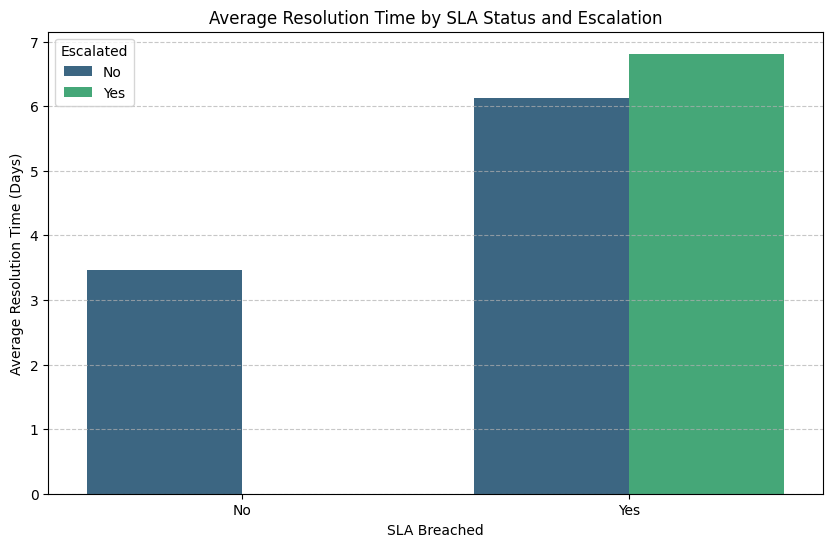

In [ ]:
avg_resolution_time_sla_escalated = df.groupby(['SLA_Breached', 'Escalated'])['Resolution_Time_Days'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='SLA_Breached', y='Resolution_Time_Days', hue='Escalated', data=avg_resolution_time_sla_escalated, palette='viridis')
plt.title('Average Resolution Time by SLA Status and Escalation')
plt.xlabel('SLA Breached')
plt.ylabel('Average Resolution Time (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Escalation Analysis by Customer Type

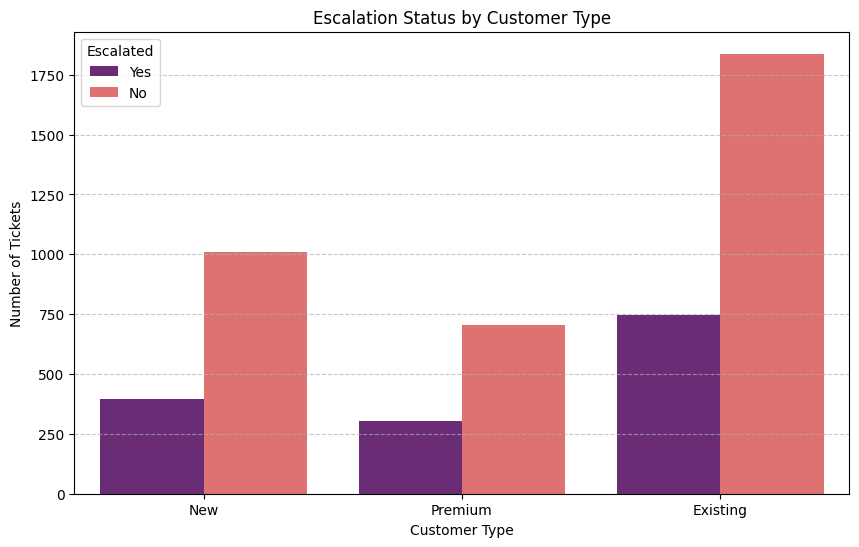

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Customer_Type', hue='Escalated', data=df, palette='magma')
plt.title('Escalation Status by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Tickets')
plt.legend(title='Escalated')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### CSAT Rating Analysis by Customer Type

/tmp/ipykernel_9022/3499923760.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Type', y='CSAT_Rating', data=avg_csat_by_customer_type, palette='coolwarm')


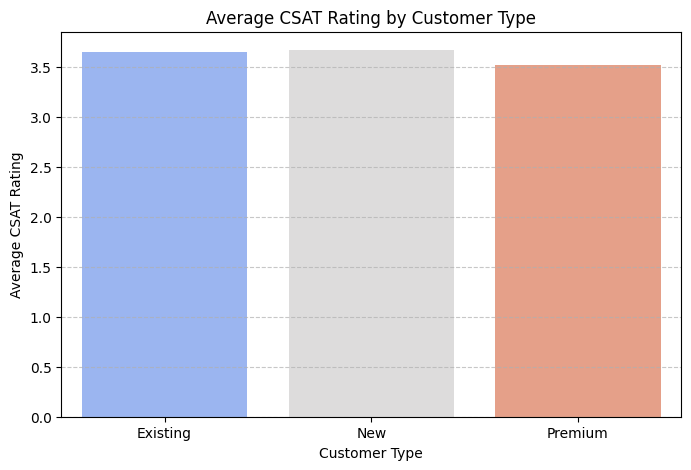

In [ ]:
avg_csat_by_customer_type = df.groupby('Customer_Type')['CSAT_Rating'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Customer_Type', y='CSAT_Rating', data=avg_csat_by_customer_type, palette='coolwarm')
plt.title('Average CSAT Rating by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average CSAT Rating')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()